# Titanic Survival Prediction using Random Forest

This project applies the Random Forest machine learning algorithm to predict whether a passenger survived the Titanic disaster.

The workflow includes:
1. Data exploration
2.Data preprocessing
3.Feature engineering
4.Model training
5.Hyperparameter tuning
6.Feature importance analysis

#Project Summary

This project demonstrates the use of the Random Forest algorithm to predict whether a passenger survived the Titanic disaster using the Titanic dataset. The dataset was first explored and preprocessed by handling missing values, encoding categorical variables, and removing unnecessary columns. The cleaned data was then divided into training and testing sets.

A Random Forest Classifier was trained on the training data to learn patterns that influence passenger survival. The model's performance was evaluated using accuracy and a confusion matrix, which shows how well the model correctly predicts survival and non-survival cases. Additionally, feature importance analysis was performed to identify which factors (such as age, sex, fare, etc.) had the most influence on the prediction.

Overall, the project shows how ensemble learning techniques like Random Forest can be used to build reliable classification models and analyze the importance of different features in real-world datasets.

#Purpose of the Code

The codes used in this project are for building a machine learning model using the Random Forest algorithm to predict passenger survival in the Titanic dataset.

First, the dataset is loaded and explored to understand its structure and the available features. Then data preprocessing is performed, which includes handling missing values, encoding categorical variables, and removing unnecessary columns.

After preprocessing, the data is split into training and testing sets so that the model can learn patterns from the training data and be evaluated on unseen data.

Next, a Random Forest Classifier is trained using the training dataset. Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The model is then evaluated using accuracy and a confusion matrix, which help measure how well the model predicts survival outcomes.

Finally, feature importance analysis is performed to identify which features (such as age, gender, or ticket class) contribute the most to the model's predictions.

Overall, these codes demonstrate the complete workflow of a machine learning project, including data preprocessing, model training, evaluation, and interpretation.

Title
1. Introduction
2. Import Libraries
3. Load Dataset
4. Data Exploration
5. Data Cleaning
6. Feature Engineering
7. Model Training
8. Model Evaluation
9. Hyperparameter Tuning
10. Feature Importance
11. Conclusion

In [1]:
#<python>
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
## Load Dataset
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
## Data Exploration
#Understanding dataset structure and statistics.
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


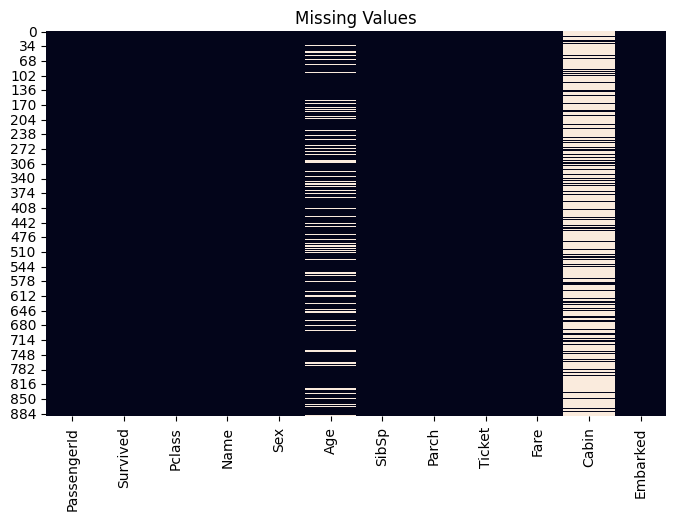

In [4]:
#Missing Values Visualization
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [22]:
# Data Cleaning
# Handling missing values


df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, errors='ignore', inplace=True)

In [23]:
#encoding
df['Sex'] = df['Sex'].map({'male':0,'female':1})

df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

In [25]:
df.drop(['PassengerId','Name','Ticket'], axis=1, errors='ignore', inplace=True)

In [26]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [27]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
#<python>
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
# Predictions
y_pred = rf_model.predict(X_test)




In [40]:
# Target
y = df['Survived']

# Features
X = df.drop('Survived', axis=1)

In [46]:
#accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7262569832402235


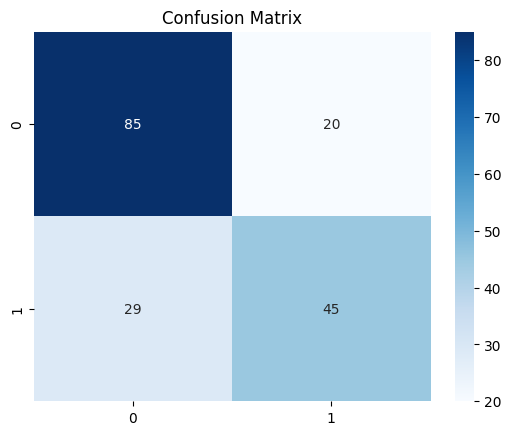

In [42]:
#consfuion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [43]:
#Feature Importance
importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importance
})

importance_df = importance_df.sort_values(by='Importance',ascending=False)

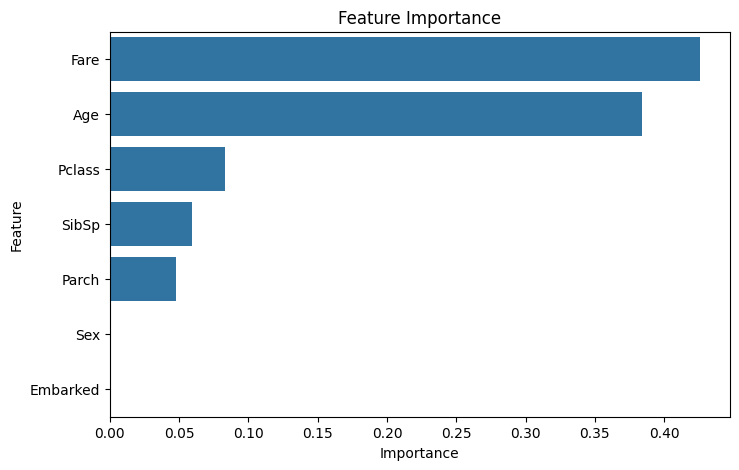

In [44]:
#Feature Importance Graph
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

## Conclusion

The Random Forest model was successfully applied to predict Titanic passenger survival.

Key results:

• Random Forest handled the dataset effectively
• Feature importance identified key survival factors
• Model achieved strong prediction accuracy

This project demonstrates the effectiveness of ensemble learning techniques in classification tasks.